# Adaptive Sigma Decay — Analysis

This notebook compares two GA runs with identical settings except for the
mutation sigma schedule:

- **fixed sigma**  -- vertex_sigma=15, color_sigma=15 throughout
- **decay sigma**  -- sigma starts high (broad exploration) and decays
  exponentially to a small value (fine refinement)

The hypothesis is that decay sigma converges to a better final fitness
because it allocates exploration budget to early generations and
exploitation budget to late generations.

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import logging
logging.basicConfig(level=logging.WARNING)

from fitness import build_fitness
from utils import load_target_pil, side_by_side, render, save_render
from ga import GeneticAlgorithm, GAConfig, EarlyStopping

from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover
from ga_operators.mutation import GaussianMutation, ResetMutation, SwapMutation, CompositeMutation, SigmaDecayScheduler

TARGET_PATH = '../data/Girl_Pearl_Earing.png'
OUTPUT_DIR  = '../outputs/sigma_decay'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('imports ok')

imports ok


In [15]:
target_pil   = load_target_pil(TARGET_PATH)
target_array = np.array(target_pil)
fitness_fn   = build_fitness('rmse', target_pil)

print(f'target: {target_pil.size}, fitness fn: {fitness_fn}')

target: (300, 400), fitness fn: RMSEFitness(target_shape=(400, 300, 3))


## 1. Visualise the decay schedule

Before running anything, plot what sigma looks like over generations
for different decay configurations.

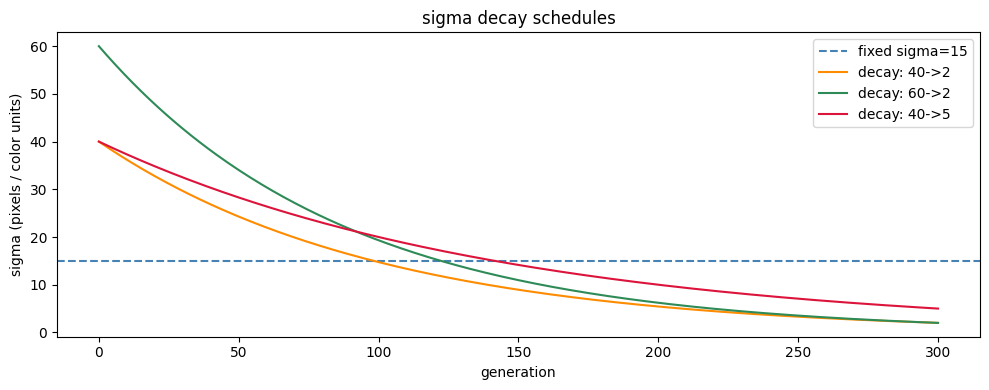

In [16]:
N_GENERATIONS = 300
T = np.arange(0, N_GENERATIONS + 1)

def decay_curve(sigma_max, sigma_min, n_gens):
    return sigma_max * (sigma_min / sigma_max) ** (T[:n_gens+1] / n_gens)

fig, ax = plt.subplots(figsize=(10, 4))

# fixed baseline
ax.axhline(15.0, color='steelblue', linestyle='--', linewidth=1.5, label='fixed sigma=15')

# decay variants
for v_max, v_min, label, color in [
    (40, 2,  'decay: 40->2',  'darkorange'),
    (60, 2,  'decay: 60->2',  'seagreen'),
    (40, 5,  'decay: 40->5',  'crimson'),
]:
    ax.plot(T[:N_GENERATIONS+1], decay_curve(v_max, v_min, N_GENERATIONS),
            label=label, color=color, linewidth=1.5)

ax.set_xlabel('generation')
ax.set_ylabel('sigma (pixels / color units)')
ax.set_title('sigma decay schedules')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/decay_schedules.png', dpi=150)
plt.show()

## 2. Shared config

In [17]:
N_GENERATIONS = 1000
POPULATION    = 50
SEED          = 42
INIT_STRATEGY = 'image'

# sigma values used for both runs
FIXED_SIGMA    = 15.0
DECAY_MAX      = 40.0
DECAY_MIN      =  2.0

def base_config():
    return GAConfig(
        population_size     = POPULATION,
        n_generations       = N_GENERATIONS,
        crossover_rate      = 0.8,
        n_elites            = 1,
        n_workers           = 1,
        early_stopping      = EarlyStopping(patience=0),  # disabled -- full run
        checkpoint_interval = 0,
        seed                = SEED,
    )

print(f'config: {POPULATION} individuals x {N_GENERATIONS} generations, seed={SEED}')
print(f'fixed sigma : {FIXED_SIGMA}')
print(f'decay sigma : {DECAY_MAX} -> {DECAY_MIN}')

config: 50 individuals x 1000 generations, seed=42
fixed sigma : 15.0
decay sigma : 40.0 -> 2.0


## 3. Run 1 — fixed sigma (baseline)

In [18]:
gaussian_fixed = GaussianMutation(
    mutation_rate   = 0.05,
    vertex_sigma    = FIXED_SIGMA,
    color_sigma     = FIXED_SIGMA,
)
mutation_fixed = CompositeMutation([
    gaussian_fixed,
    ResetMutation(mutation_rate=0.01),
    SwapMutation(mutation_rate=0.2, n_swaps=1),
])

ga_fixed = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=5),
    crossover  = SinglePointCrossover(),
    mutation   = mutation_fixed,
    config     = base_config(),
)

print('running fixed sigma ...', end=' ', flush=True)
best_fixed = ga_fixed.run(target=target_array, init_strategy=INIT_STRATEGY)
log_fixed  = pd.DataFrame(ga_fixed.generation_log)
print(f'done. best fitness = {best_fixed.fitness:.4f}')

running fixed sigma ... done. best fitness = 34.0123


## 4. Run 2 — adaptive sigma decay

In [19]:
# gaussian_decay is the object the scheduler will mutate in place
gaussian_decay = GaussianMutation(
    mutation_rate   = 0.05,
    vertex_sigma    = DECAY_MAX,   # start value -- scheduler will update this
    color_sigma     = DECAY_MAX,
)
mutation_decay = CompositeMutation([
    gaussian_decay,
    ResetMutation(mutation_rate=0.01),
    SwapMutation(mutation_rate=0.2, n_swaps=1),
])

scheduler = SigmaDecayScheduler(
    mutation         = gaussian_decay,
    n_generations    = N_GENERATIONS,
    vertex_sigma_max = DECAY_MAX,
    vertex_sigma_min = DECAY_MIN,
    color_sigma_max  = DECAY_MAX,
    color_sigma_min  = DECAY_MIN,
)

ga_decay = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=5),
    crossover  = SinglePointCrossover(),
    mutation   = mutation_decay,
    config     = base_config(),
)

print('running decay sigma ...', end=' ', flush=True)
best_decay = ga_decay.run(
    target        = target_array,
    init_strategy = INIT_STRATEGY,
    callback      = scheduler,
)
log_decay     = pd.DataFrame(ga_decay.generation_log)
log_sigma     = pd.DataFrame(scheduler.sigma_log)
print(f'done. best fitness = {best_decay.fitness:.4f}')

running decay sigma ... done. best fitness = 30.6796


## 5. Convergence comparison

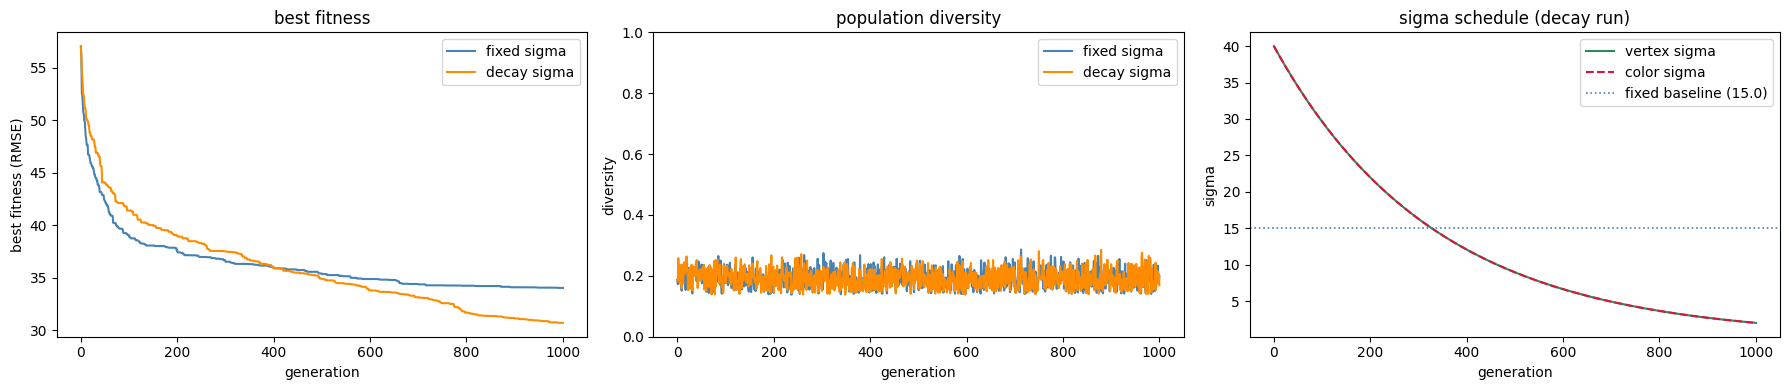

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# left: best fitness
ax = axes[0]
ax.plot(log_fixed['generation'], log_fixed['best'],
        label='fixed sigma', color='steelblue', linewidth=1.5)
ax.plot(log_decay['generation'], log_decay['best'],
        label='decay sigma', color='darkorange', linewidth=1.5)
ax.set_xlabel('generation')
ax.set_ylabel('best fitness (RMSE)')
ax.set_title('best fitness')
ax.legend()

# middle: population diversity
ax2 = axes[1]
ax2.plot(log_fixed['generation'], log_fixed['diversity'],
         label='fixed sigma', color='steelblue', linewidth=1.5)
ax2.plot(log_decay['generation'], log_decay['diversity'],
         label='decay sigma', color='darkorange', linewidth=1.5)
ax2.set_xlabel('generation')
ax2.set_ylabel('diversity')
ax2.set_title('population diversity')
ax2.set_ylim(0, 1)
ax2.legend()

# right: actual sigma over time (decay run only)
ax3 = axes[2]
ax3.plot(log_sigma['generation'], log_sigma['vertex_sigma'],
         label='vertex sigma', color='seagreen', linewidth=1.5)
ax3.plot(log_sigma['generation'], log_sigma['color_sigma'],
         label='color sigma', color='crimson', linewidth=1.5, linestyle='--')
ax3.axhline(FIXED_SIGMA, color='steelblue', linestyle=':', linewidth=1.2,
            label=f'fixed baseline ({FIXED_SIGMA})')
ax3.set_xlabel('generation')
ax3.set_ylabel('sigma')
ax3.set_title('sigma schedule (decay run)')
ax3.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence_comparison.png', dpi=150)
plt.show()

## 6. Summary table

In [21]:
rows = []
for label, log, best in [
    ('fixed sigma', log_fixed, best_fixed),
    ('decay sigma', log_decay, best_decay),
]:
    rows.append({
        'run':              label,
        'gen0_fitness':     round(log['best'].iloc[0],  4),
        'final_fitness':    round(log['best'].iloc[-1], 4),
        'improvement':      round(log['best'].iloc[0] - log['best'].iloc[-1], 4),
        'final_diversity':  round(log['diversity'].iloc[-1], 4),
        'elapsed_s':        round(log['elapsed_s'].iloc[-1], 1),
    })

summary = pd.DataFrame(rows).set_index('run')
summary.to_csv(f'{OUTPUT_DIR}/summary.csv')
display(summary)

,gen0_fitness,final_fitness,improvement,final_diversity,elapsed_s
run,,,,,
fixed sigma,57.0502,34.0123,23.0379,0.1993,410.1
decay sigma,57.0502,30.6796,26.3706,0.1691,30239.6


## 7. Visual comparison of best individuals

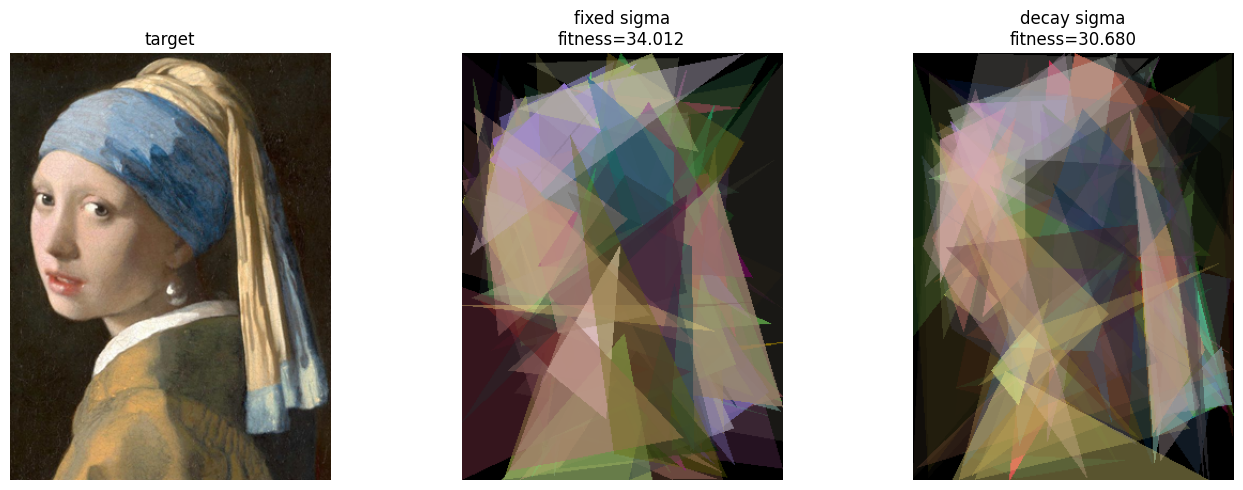

In [22]:
arr_fixed = render(best_fixed.triangles)
arr_decay = render(best_decay.triangles)

save_render(arr_fixed, f'{OUTPUT_DIR}/best_fixed.png')
save_render(arr_decay, f'{OUTPUT_DIR}/best_decay.png')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, arr, title in zip(
    axes,
    [target_array, arr_fixed, arr_decay],
    [
        'target',
        f'fixed sigma\nfitness={best_fixed.fitness:.3f}',
        f'decay sigma\nfitness={best_decay.fitness:.3f}',
    ],
):
    ax.imshow(arr)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/visual_comparison.png', dpi=150)
plt.show()

## 8. Sigma sensitivity sweep (optional)

Try multiple decay configurations and compare final fitness.
Useful for finding good sigma_max and sigma_min values.
Comment out this cell if runtime is a concern.

In [23]:
configs = [
    {'v_max': 40, 'v_min': 2,  'c_max': 40, 'c_min': 2},
    {'v_max': 60, 'v_min': 2,  'c_max': 60, 'c_min': 2},
    {'v_max': 40, 'v_min': 5,  'c_max': 40, 'c_min': 5},
    {'v_max': 20, 'v_min': 1,  'c_max': 20, 'c_min': 1},
]

sweep_results = []

for cfg in configs:
    label = f"v:{cfg['v_max']}->{cfg['v_min']} c:{cfg['c_max']}->{cfg['c_min']}"
    print(f'running {label} ...', end=' ', flush=True)

    g_mut = GaussianMutation(mutation_rate=0.05,
                             vertex_sigma=cfg['v_max'],
                             color_sigma=cfg['c_max'])
    sched = SigmaDecayScheduler(
        mutation         = g_mut,
        n_generations    = N_GENERATIONS,
        vertex_sigma_max = cfg['v_max'],
        vertex_sigma_min = cfg['v_min'],
        color_sigma_max  = cfg['c_max'],
        color_sigma_min  = cfg['c_min'],
    )
    mut = CompositeMutation([
        g_mut,
        ResetMutation(mutation_rate=0.01),
        SwapMutation(mutation_rate=0.2, n_swaps=1),
    ])
    ga = GeneticAlgorithm(
        fitness_fn = fitness_fn,
        selection  = TournamentSelection(tournament_size=5),
        crossover  = SinglePointCrossover(),
        mutation   = mut,
        config     = base_config(),
    )
    best = ga.run(target=target_array, init_strategy=INIT_STRATEGY, callback=sched)
    log  = pd.DataFrame(ga.generation_log)

    sweep_results.append({
        'config':        label,
        'final_fitness': round(best.fitness, 4),
        'improvement':   round(log['best'].iloc[0] - log['best'].iloc[-1], 4),
        'elapsed_s':     round(log['elapsed_s'].iloc[-1], 1),
    })
    print(f'fitness = {best.fitness:.4f}')

sweep_df = pd.DataFrame(sweep_results).set_index('config')
sweep_df.to_csv(f'{OUTPUT_DIR}/sweep_results.csv')
display(sweep_df.sort_values('final_fitness'))

running v:40->2 c:40->2 ... 

KeyboardInterrupt: 